
<h1 dir="rtl" style="font-family: Vazir; width: 85%;">تمرین شماره ۱: درس بازیابی هوشمند اطلاعات - دانشگاه تهران، پائیز ۱۴۰۴</h1>

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
نام: امیرپارسا موبد
<br/>
شماره دانشجویی: ۸۱۰۱۰۰۲۷۱

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
سوالات خودتان را می‌توانید از طریق ایمیل
<code>kargaran.sina@gmail.com</code>
 از طراح تمرین ۱ بپرسید.

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px; color: red; font-weight: bold;">
قوانین و توضیحاتی آخر فایل تمرین حتما به دقت مطالعه شود.
</div>

In [1]:
!pip install nltk
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install ir_datasets


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 2.5 MB/s eta 0:00:00a 0:00:01
  DEPRECATION: Building 'cbo

In [22]:
import document_processing as dp
import inverted_index as ii
import query_processing as qp
import evaluation as ev

In [23]:
import importlib
import retrieval_models as rm  # Your initial import

# ... after you make changes to retrieval_models.py ...
importlib.reload(rm)  # This loads the latest version

<module 'retrieval_models' from '/Users/amirparsamobed/Documents/University/Term 9/Intelligent Information Retrieval/Github repository/CA1/code/retrieval_models.py'>

In [5]:
# Ensure NLTK data is downloaded
import nltk
import numpy as np
import pandas as pd

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/amirparsamobed/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amirparsamobed/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amirparsamobed/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

<div dir="rtl" style="font-family: Vazir; width: 90%; font-size: 17px; line-height: 1.9;"> <h3 style="color: #8B0000;">پاسخ پرسش‌های مقدماتی</h3> <p><strong>پردازش انجام‌شده روی اسناد و عبارات جستجو چیست و چرا انجام می‌شود؟</strong></p> <p> در هر دو مرحلهٔ پردازش اسناد و پردازش کوئری، متن ابتدا از نویسه‌های غیرحرفی پاک‌سازی شده و سپس توکن‌سازی می‌شود. پس از آن همهٔ واژه‌ها به حروف کوچک تبدیل شده، واژگان پرتکرار با فهرست <code>stopwords</code> حذف و در نهایت ریشه‌یابی Porter روی باقی‌ماندهٔ واژه‌ها اعمال می‌شود. این زنجیرهٔ پردازش سه هدف اصلی دارد: </p> <ul> <li>یکسان‌سازی شکل‌های نوشتاری برای کاهش تنوع ظاهری (مثلاً study، studies، studying → study)</li> <li>کاهش نویز و حذف واژه‌هایی که در تصمیم‌گیری نقشی ندارند (مانند the، of، and)</li> <li>کاهش ابعاد فضای برداری و پایداری بیشتر محاسباتی برای وزن‌دهی‌ها (TF، IDF، BM25)</li> </ul> <p> به‌صورت کلی، این پیش‌پردازش باعث می‌شود ترم‌های مشترک میان سند و کوئری دقیق‌تر شناسایی شوند، اختلاف‌های ظاهری حذف گردد، و مدل‌های رتبه‌بندی بتوانند به‌جای شکل واژه‌ها بر معنای واژه‌ها تمرکز کنند. </p> <hr> <p><strong>شاخص‌گذاری اسناد به چه شکلی انجام می‌شود؟</strong></p> <p> پس از پیش‌پردازش، هر سند با استفاده از شمارشگر <code>Counter</code> تحلیل شده و فراوانی هر ترم در سند مشخص می‌شود. سپس در <code>InvertedIndex.build_index</code> ورودی‌ها به ساختار ایندکس معکوس تزریق می‌شوند: برای هر ترم، زوج‌های <code>(doc_id, freq)</code> ذخیره شده و هم‌زمان اطلاعاتی چون طول سند، تعداد کل اسناد، میانگین طول اسناد و تعداد اسنادی که ترم را شامل می‌شوند به‌روزرسانی می‌گردد. نگهداری نسخهٔ توکن‌شدهٔ سند (<code>doc_tokens</code>) نیز امکان انجام تحلیل‌های تکمیلی یا مدل‌های پیشرفته‌تر را فراهم می‌کند. </p> <p> به دلیل استفاده از یک ساختار ایندکس معکوس، واکشی اسناد حاوی یک ترم به جای پیمایش کل اسناد، تنها با مراجعه به لیست پست‌های همان ترم انجام می‌شود که زمان پرس‌وجو را به‌شدت کاهش می‌دهد. </p> <hr> <h3 style="color: #8B0000;">تحقیق مختصر دربارهٔ ساختارهای شاخص‌گذاری رایج</h3> <p><strong>۱) Lexicon</strong></p> <p> لکسیکون فرهنگ واژگانی موتور جستجو است؛ ساختاری که برای هر ترم ورودی زیر را نگه می‌دارد: </p> <ul> <li>شناسهٔ داخلی ترم</li> <li>تعداد اسنادی که ترم در آن‌ها ظاهر شده است (<code>df</code>)</li> <li>اطلاعاتی برای محاسبهٔ وزن‌هایی مثل <code>IDF</code></li> <li>اشاره‌گر به لیست پست‌های ترم</li> </ul> <p> در این پروژه کلیدهای دیکشنری <code>inverted_index.index</code> دقیقاً همین نقش را ایفا می‌کنند و ساختاری معادل یک Lexicon ساده محسوب می‌شوند. </p> <hr> <p><strong>۲) Posting Index / Inverted Index</strong></p> <p> ایندکس معکوس مهم‌ترین ساختار داده‌ای در بازیابی اطلاعات است. این ساختار برای هر ترم یک لیست شامل زوج‌های <code>(doc_id, freq)</code> نگه می‌دارد و ترتیب doc_idها معمولاً صعودی است تا عملیات‌های ادغامی (مثل intersect دو ترم) سریع انجام شود. </p> <p> در اجرای این تمرین، <code>self.index[term]</code> همان Posting List است و توسط مدل‌هایی مثل BM25 و Pivoted برای محاسبهٔ امتیاز اسناد استفاده می‌شود. مزیت اصلی این ساختار، واکشی سریع اسناد مرتبط و امکان پیاده‌سازی رتبه‌بندی‌ها در زمان بسیار کمتر از پیمایش مجموعهٔ کامل اسناد است. </p> <hr> <p><strong>۳) DocumentIndex</strong></p> <p> DocumentIndex پایگاه دادهٔ اطلاعات پایهٔ هر سند است. مواردی مانند: </p> <ul> <li>طول سند</li> <li>فهرست سادهٔ ترم‌های سند</li> <li>میانگین طول تمام سندها</li> <li>تعداد کل اسناد</li> </ul> <p> در فایل <code>inverted_index.py</code> متغیرهایی مثل <code>doc_lengths</code>، <code>doc_tokens</code> و <code>doc_count</code> همین نقش را انجام می‌دهند. این اطلاعات مستقیماً در فرمول‌های رتبه‌بندی مانند BM25 و Pivoted Length Normalization استفاده می‌شوند. </p> <hr> <p><strong>۴) MetaIndex</strong></p> <p> متاایندکس معمولاً شامل نگاشت‌های کمکی است؛ مثل ارتباط شناسهٔ داخلی اسناد با شناسهٔ واقعی، عنوان، نویسنده، تاریخ انتشار یا نوع محتوا. در موتورهای جستجوی واقعی، MetaIndex بخش مهمی از سیستم است زیرا به رندر نتایج، فیلترگذاری، فیلدهای جستجو (title/body/url) و نمایش snippet کمک می‌کند. </p> <p> در این تمرین ساختار مستقلی برای MetaIndex ایجاد نشده، اما ذخیرهٔ اشیاء <code>Document</code> همراه با <code>metadata</code> و دیکشنری <code>doc_tokens</code> امکان افزودن و استفاده از چنین داده‌هایی را فراهم کرده و نقش مشابه یک MetaIndex ساده را ایفا می‌کند. </p> </div>

# **سوال اول:**

## Loading the dataset 1

In [6]:
# 1. Data Loading and Preprocessing

print("Loading and preprocessing documents...")
documents = dp.load_documents()
for idx, doc in enumerate(documents):
    doc.preprocess()
    if (idx + 1) % 40_000 == 0 or idx == len(documents) - 1:
        print(f"Processed {idx+1}/{len(documents)} documents")

print("Building inverted index...")
inverted_index = ii.InvertedIndex()
inverted_index.build_index(documents)

print("Loading and preprocessing queries...")
queries = qp.load_queries()
for query in queries:
    query.preprocess()

print("Loading relevance judgments...")
relevance_judgments = ev.load_relevance_judgments()

Loading and preprocessing documents...


[INFO] Please confirm you agree to the authors' data usage agreement found at <https://ciir.cs.umass.edu/downloads/Antique/readme.txt>
[INFO] If you have a local copy of https://ciir.cs.umass.edu/downloads/Antique/antique-collection.txt, you can symlink it here to avoid downloading it again: /Users/amirparsamobed/.ir_datasets/downloads/684f7015aff377062a758e478476aac8
[INFO] [starting] https://ciir.cs.umass.edu/downloads/Antique/antique-collection.txt
[INFO] [finished] https://ciir.cs.umass.edu/downloads/Antique/antique-collection.txt: [03:30] [93.6MB] [444kB/s]


Processed 40000/403666 documents
Processed 80000/403666 documents
Processed 120000/403666 documents
Processed 160000/403666 documents
Processed 200000/403666 documents
Processed 240000/403666 documents
Processed 280000/403666 documents
Processed 320000/403666 documents
Processed 360000/403666 documents
Processed 400000/403666 documents
Processed 403666/403666 documents
Building inverted index...
Loading and preprocessing queries...


[INFO] [starting] https://ciir.cs.umass.edu/downloads/Antique/antique-test-queries.txt
[INFO] [finished] https://ciir.cs.umass.edu/downloads/Antique/antique-test-queries.txt: [00:00] [11.4kB] [121kB/s]


Loading relevance judgments...


[INFO] [starting] https://ciir.cs.umass.edu/downloads/Antique/antique-test.qrel
[INFO] [finished] https://ciir.cs.umass.edu/downloads/Antique/antique-test.qrel: [00:00] [150kB] [464kB/s]


## Example

In [7]:
print("\nSample run with BM25 (k=1.2, b=0.75)")
params = {'k': 1.2, 'b': 0.75}
evaluation_results = ev.evaluate_scoring_method(inverted_index,rm.bm25_score, queries, relevance_judgments, params=params)
print(evaluation_results)
print(f"MAP for BM25 (k={1.2}, b={0.75}): {evaluation_results['MAP']}")


Sample run with BM25 (k=1.2, b=0.75)
{'MAP': 0.1964, 'MRR': 0.5054, 'Precision@3': 0.3083, 'Precision@10': 0.234, 'Recall@3': 0.0852, 'Recall@10': 0.2003, 'nDCG@10': 0.3976}
MAP for BM25 (k=1.2, b=0.75): 0.1964


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
<h3 style="color: #17b712ff;">رویکرد جست‌وجوی دو نرخ</h3> 
برای هر مدل ابتدا شبکه‌ای با گام‌های بزرگ 
(coarse grid) 
را بررسی می‌کنم تا ناحیهٔ تقریبی پارامترهای خوب مشخص شود. با توجه به این‌که همهٔ مدل‌ها تابع هزینهٔ صریح و مشتق‌پذیر ندارند و احتمال گیر افتادن در بهینه‌های محلی وجود دارد، جست‌وجوی شبکه‌ای گزینهٔ قابل اتکایی است؛ بعد از آن در بهترین ناحیه پیدا شده، شبکهٔ کوچک‌تری 
(fine grid)
اطراف همان ناحیه می‌سازم تا مقدار دقیق‌تری به‌دست بیاید. این 
workflow
کمک کی‌کند که بتوان در پایان گام اول و دوم جدول هیت‌مپی از نتایج ارائه داد که هم نمای کلی از رفتار مدل می‌دهد و هم بهترین پارامترها را با دقت بیشتری نشان می‌دهد. این روش
منطبق با توصیهٔ صورت تمرین (گام‌های بلند سپس گام‌های کوچک) است و کنترل خوبی روی مصرف زمان آزمون‌ها می‌دهد.

=== BM25: Coarse grid ===
BM25 (coarse) params={'k': 0.2, 'b': 0.1} -> MAP=0.2032
BM25 (coarse) params={'k': 0.2, 'b': 0.3} -> MAP=0.2218
BM25 (coarse) params={'k': 0.2, 'b': 0.5} -> MAP=0.2246
BM25 (coarse) params={'k': 0.2, 'b': 0.7} -> MAP=0.2203
BM25 (coarse) params={'k': 0.2, 'b': 0.9} -> MAP=0.2141
BM25 (coarse) params={'k': 0.63, 'b': 0.1} -> MAP=0.2147
BM25 (coarse) params={'k': 0.63, 'b': 0.3} -> MAP=0.2408
BM25 (coarse) params={'k': 0.63, 'b': 0.5} -> MAP=0.2368
BM25 (coarse) params={'k': 0.63, 'b': 0.7} -> MAP=0.2189
BM25 (coarse) params={'k': 0.63, 'b': 0.9} -> MAP=0.1965
BM25 (coarse) params={'k': 1.07, 'b': 0.1} -> MAP=0.2095
BM25 (coarse) params={'k': 1.07, 'b': 0.3} -> MAP=0.2395
BM25 (coarse) params={'k': 1.07, 'b': 0.5} -> MAP=0.2309
BM25 (coarse) params={'k': 1.07, 'b': 0.7} -> MAP=0.2063
BM25 (coarse) params={'k': 1.07, 'b': 0.9} -> MAP=0.1720
BM25 (coarse) params={'k': 1.5, 'b': 0.1} -> MAP=0.2019
BM25 (coarse) params={'k': 1.5, 'b': 0.3} -> MAP=0.2309
BM25 (coarse

,k,b,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.63,0.3,0.2408,0.6229,0.4200,0.2905,0.1101,0.2371,0.4346
1,1.07,0.3,0.2395,0.6146,0.4117,0.2910,0.1069,0.2359,0.4373
2,0.63,0.5,0.2368,0.5982,0.3983,0.2870,0.1076,0.2345,0.4419
3,1.07,0.5,0.2309,0.5876,0.3867,0.2790,0.1049,0.2273,0.4383
4,1.50,0.3,0.2309,0.6016,0.3967,0.2865,0.1024,0.2277,0.4290
5,1.93,0.3,0.2248,0.5945,0.3917,0.2735,0.1015,0.2183,0.4169
6,0.20,0.5,0.2246,0.5685,0.3883,0.2720,0.1071,0.2229,0.4131
7,1.50,0.5,0.2225,0.5751,0.3767,0.2720,0.1008,0.2214,0.4296


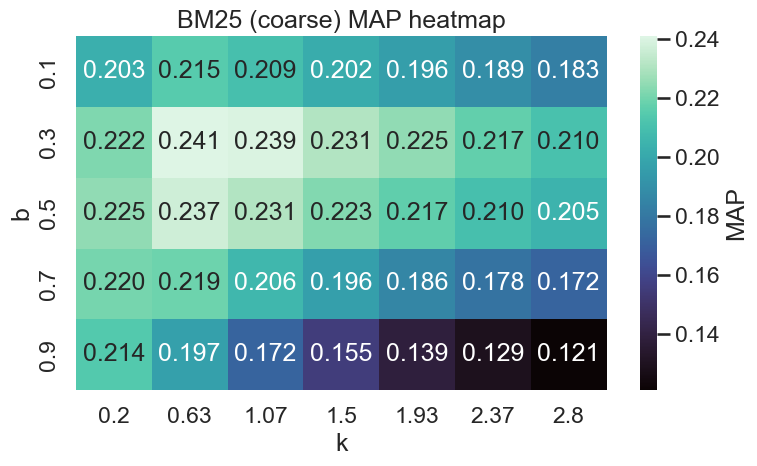

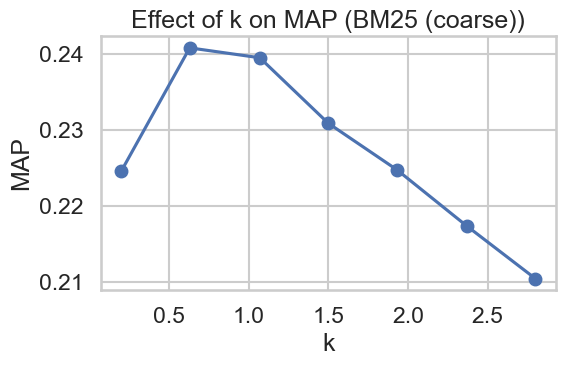

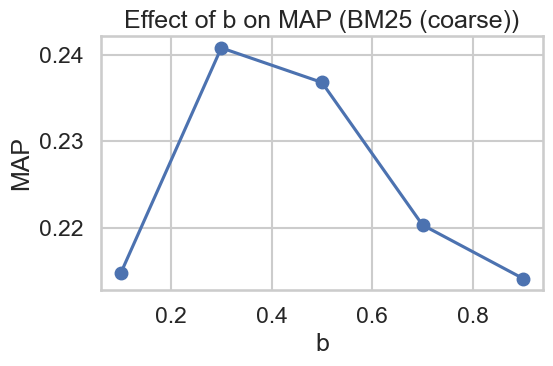

Refined grid for BM25: {'k': array([0.33, 0.43, 0.53, 0.63, 0.73, 0.83, 0.93]), 'b': array([0.2 , 0.25, 0.3 , 0.35, 0.4 ])}
Best BM25 (fine) based on MAP: params={'k': 0.63, 'b': 0.4} -> MAP=0.2428


,k,b,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.63,0.40,0.2428,0.6220,0.4117,0.2980,0.1092,0.2428,0.4463
1,0.83,0.30,0.2423,0.6296,0.4183,0.2905,0.1088,0.2361,0.4387
2,0.83,0.35,0.2422,0.6238,0.4050,0.2955,0.1067,0.2401,0.4445
3,0.73,0.40,0.2420,0.6155,0.4100,0.2960,0.1088,0.2409,0.4470
4,0.73,0.35,0.2420,0.6209,0.4100,0.2945,0.1085,0.2401,0.4428
5,0.73,0.30,0.2420,0.6234,0.4167,0.2920,0.1094,0.2383,0.4382
6,0.53,0.40,0.2414,0.6167,0.4117,0.2935,0.1091,0.2374,0.4414
7,0.83,0.40,0.2411,0.6100,0.4117,0.2950,0.1087,0.2368,0.4457


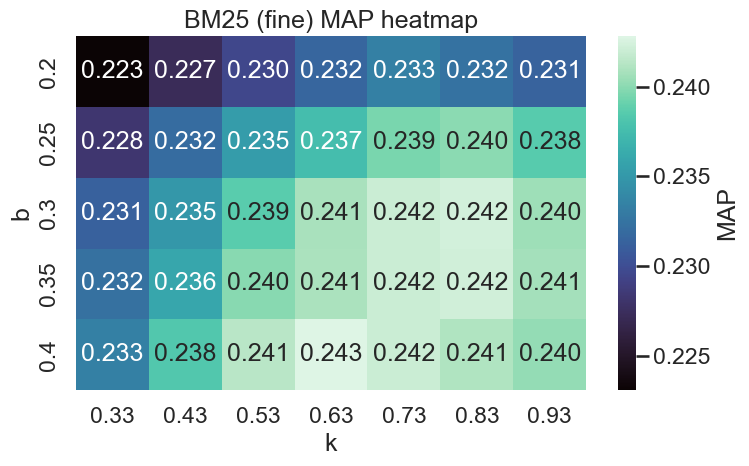

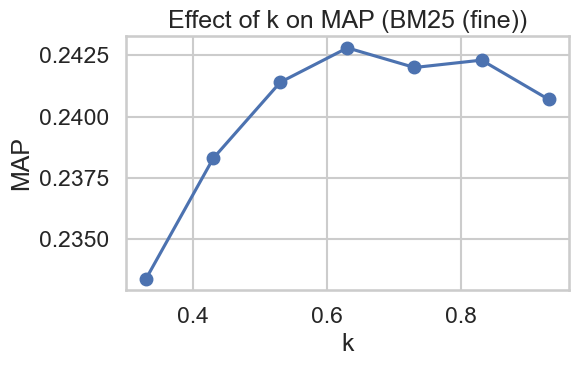

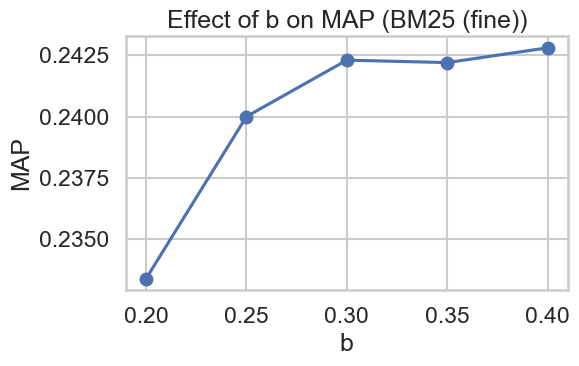

Final choice for BM25: {'k': 0.63, 'b': 0.4} with MAP=0.2428
Full metric profile: {'MAP': 0.2428, 'MRR': 0.622, 'Precision@3': 0.4117, 'Precision@10': 0.298, 'Recall@3': 0.1092, 'Recall@10': 0.2428, 'nDCG@10': 0.4463}


(       k    b     MAP     MRR  Precision@3  Precision@10  Recall@3  Recall@10  \
 0   0.63  0.3  0.2408  0.6229       0.4200        0.2905    0.1101     0.2371   
 1   1.07  0.3  0.2395  0.6146       0.4117        0.2910    0.1069     0.2359   
 2   0.63  0.5  0.2368  0.5982       0.3983        0.2870    0.1076     0.2345   
 3   1.07  0.5  0.2309  0.5876       0.3867        0.2790    0.1049     0.2273   
 4   1.50  0.3  0.2309  0.6016       0.3967        0.2865    0.1024     0.2277   
 5   1.93  0.3  0.2248  0.5945       0.3917        0.2735    0.1015     0.2183   
 6   0.20  0.5  0.2246  0.5685       0.3883        0.2720    0.1071     0.2229   
 7   1.50  0.5  0.2225  0.5751       0.3767        0.2720    0.1008     0.2214   
 8   0.20  0.3  0.2218  0.5594       0.3950        0.2755    0.1065     0.2231   
 9   0.20  0.7  0.2203  0.5532       0.3650        0.2635    0.1016     0.2188   
 10  0.63  0.7  0.2189  0.5498       0.3450        0.2585    0.0945     0.2175   
 11  2.37  0.3  

In [ ]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set(style="whitegrid", context="talk")

tuned_models = {}


def _as_scalar(value):
    """Convert numpy scalars to native Python values for clean printing."""
    return value.item() if hasattr(value, "item") else value


def iterate_param_grid(param_ranges):
    """Yield every parameter combination defined by param_ranges."""
    keys = list(param_ranges.keys())
    values = []
    for key in keys:
        series = param_ranges[key]
        if isinstance(series, (list, tuple)):
            values.append([_as_scalar(v) for v in series])
        else:
            values.append([_as_scalar(v) for v in list(series)])
    if not keys:
        yield {}
        return
    for combo in itertools.product(*values):
        yield dict(zip(keys, combo))


def evaluate_param_grid(model_fn, param_ranges, model_name, metric="MAP", min_relevant=3, verbose=True):
    """Evaluate every combination and return a sorted DataFrame plus the best params."""
    rows = []
    for params in iterate_param_grid(param_ranges):
        eval_result = ev.evaluate_scoring_method(
            inverted_index,
            model_fn,
            queries,
            relevance_judgments,
            params=params,
            min_relevant=min_relevant,
        )
        if verbose:
            print(f"{model_name:<12} params={params or '<none>'} -> {metric}={eval_result[metric]:.4f}")
        rows.append({**params, **eval_result})

    results_df = (
        pd.DataFrame(rows)
        .sort_values(metric, ascending=False)
        .reset_index(drop=True)
    )
    param_names = list(param_ranges.keys())
    best_row = results_df.iloc[0]
    best_params = {name: _as_scalar(best_row[name]) for name in param_names}
    metric_columns = [col for col in results_df.columns if col not in param_names]
    best_metrics = {col: best_row[col] for col in metric_columns}
    print(
        f"Best {model_name} based on {metric}: params={best_params or '<none>'} -> {metric}={best_metrics[metric]:.4f}"
    )
    return results_df, best_params, best_metrics


def plot_param_effects(results_df, param_names, metric="MAP", model_name="Model"):
    """Draw heatmap + per-parameter trends to visualize sensitivity."""
    if not param_names:
        print(f"{model_name}: پارامتری برای رسم نمودار وجود ندارد.")
        return

    if len(param_names) == 2:
        x, y = param_names[0], param_names[1]
        pivot = results_df.pivot(index=y, columns=x, values=metric)
        pivot = pivot.sort_index().sort_index(axis=1)
        plt.figure(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="mako", cbar_kws={"label": metric})
        plt.title(f"{model_name} {metric} heatmap")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()

    for param in param_names:
        plt.figure(figsize=(6, 4))
        series = (
            results_df.groupby(param, as_index=False)[metric]
            .max()
            .sort_values(param)
        )
        plt.plot(series[param], series[metric], marker="o")
        plt.title(f"Effect of {param} on {metric} ({model_name})")
        plt.xlabel(param)
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()


def build_refined_ranges(best_params, bounds, windows, points):
    """Create a finer grid centered on best_params while respecting bounds."""
    fine_ranges = {}
    for name, best in best_params.items():
        low_bound, high_bound = bounds[name]
        window = windows.get(name, 0.2)
        count = points.get(name, 5)
        start = max(low_bound, best - window)
        end = min(high_bound, best + window)
        if np.isclose(start, end):
            fine_ranges[name] = [round(float(start), 3)]
        else:
            fine_ranges[name] = np.round(np.linspace(start, end, count), 3)
    return fine_ranges


def two_stage_search(model_name, scoring_fn, coarse_grid, bounds=None, windows=None, points=None, metric="MAP", show_rows=8, plot=True):
    """Run coarse and fine grid search, then register best params globally."""
    print(f"=== {model_name}: Coarse grid ===")
    coarse_results, coarse_best_params, coarse_best_metrics = evaluate_param_grid(
        scoring_fn,
        coarse_grid,
        model_name=f"{model_name} (coarse)",
        metric=metric,
    )
    if show_rows and not coarse_results.empty:
        display(coarse_results.head(show_rows))
    if plot:
        plot_param_effects(coarse_results, list(coarse_grid.keys()), model_name=f"{model_name} (coarse)")

    fine_results = None
    fine_best_params = coarse_best_params
    fine_best_metrics = coarse_best_metrics

    if bounds and windows and points and coarse_best_params:
        fine_grid = build_refined_ranges(
            coarse_best_params,
            bounds=bounds,
            windows=windows,
            points=points,
        )
        print(f"Refined grid for {model_name}: {fine_grid}")
        fine_results, fine_best_params, fine_best_metrics = evaluate_param_grid(
            scoring_fn,
            fine_grid,
            model_name=f"{model_name} (fine)",
            metric=metric,
            verbose=False,
        )
        if show_rows and fine_results is not None:
            display(fine_results.head(show_rows))
        if plot:
            plot_param_effects(fine_results, list(fine_grid.keys()), model_name=f"{model_name} (fine)")
    else:
        fine_grid = None

    tuned_models[model_name] = {
        "params": fine_best_params,
        "metrics": fine_best_metrics,
        "coarse_grid": coarse_grid,
        "fine_grid": fine_grid,
    }
    print(f"Final choice for {model_name}: {fine_best_params or '<none>'} with {metric}={fine_best_metrics[metric]:.4f}")
    print("Full metric profile:", fine_best_metrics)
    return coarse_results, fine_results, fine_best_params, fine_best_metrics


bm25_bounds = {"k": (0.0, 3.0), "b": (0.0, 1.0)}
bm25_coarse = {
    "k": np.round(np.linspace(0.2, 2.8, 7), 2),
    "b": np.round(np.linspace(0.1, 0.9, 5), 2),
}

two_stage_search(
    model_name="BM25",
    scoring_fn=rm.bm25_score,
    coarse_grid=bm25_coarse,
    bounds=bm25_bounds,
    windows={"k": 0.3, "b": 0.1},
    points={"k": 7, "b": 5},
)




In [13]:
def plot_param_effects(results_df, param_names, metric="MAP", model_name="Model"):
    """Draw heatmap + per-parameter trends to visualize sensitivity."""
    if not param_names:
        print(f"{model_name}: پارامتری برای رسم نمودار وجود ندارد.")
        return

    if len(param_names) == 2:
        x, y = param_names[0], param_names[1]
        pivot = results_df.pivot(index=y, columns=x, values=metric)
        pivot = pivot.sort_index().sort_index(axis=1)
        plt.figure(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="mako", cbar_kws={"label": metric})
        plt.title(f"{model_name} {metric} heatmap")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()

    for param in param_names:
        plt.figure(figsize=(6, 4))
        series = (
            results_df.groupby(param, as_index=False)[metric]
            .max()
            .sort_values(param)
        )
        plt.plot(series[param], series[metric], marker="o")
        plt.title(f"Effect of {param} on {metric} ({model_name})")
        plt.xlabel(param)
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()


=== Method 1 - IDF overlap: Coarse grid ===
Method 1 - IDF overlap (coarse) params=<none> -> MAP=0.1499
Best Method 1 - IDF overlap (coarse) based on MAP: params=<none> -> MAP=0.1499


,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.1499,0.4257,0.2517,0.1725,0.0745,0.155,0.2528


Method 1 - IDF overlap (coarse): پارامتری برای رسم نمودار وجود ندارد.
Final choice for Method 1 - IDF overlap: <none> with MAP=0.1499
Full metric profile: {'MAP': 0.1499, 'MRR': 0.4257, 'Precision@3': 0.2517, 'Precision@10': 0.1725, 'Recall@3': 0.0745, 'Recall@10': 0.155, 'nDCG@10': 0.2528}
=== Method 2 - Saturated TF: Coarse grid ===
Method 2 - Saturated TF (coarse) params={'k': 0.3} -> MAP=0.1256
Method 2 - Saturated TF (coarse) params={'k': 0.9} -> MAP=0.1209
Method 2 - Saturated TF (coarse) params={'k': 1.5} -> MAP=0.1103
Method 2 - Saturated TF (coarse) params={'k': 2.1} -> MAP=0.0990
Method 2 - Saturated TF (coarse) params={'k': 2.7} -> MAP=0.0926
Best Method 2 - Saturated TF (coarse) based on MAP: params={'k': 0.3} -> MAP=0.1256


,k,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.3,0.1256,0.4025,0.2350,0.1640,0.0603,0.1329,0.2234
1,0.9,0.1209,0.3999,0.2283,0.1600,0.0576,0.1315,0.2181
2,1.5,0.1103,0.3697,0.2083,0.1530,0.0527,0.1228,0.2029
3,2.1,0.0990,0.3549,0.1867,0.1390,0.0463,0.1089,0.1863
4,2.7,0.0926,0.3359,0.1633,0.1295,0.0381,0.1024,0.1740


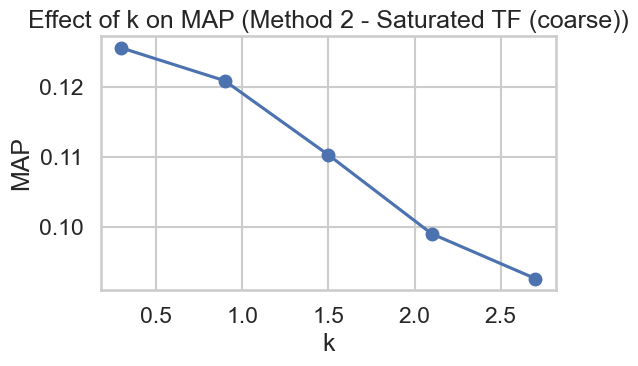

Refined grid for Method 2 - Saturated TF: {'k': array([0.   , 0.117, 0.233, 0.35 , 0.467, 0.583, 0.7  ])}
Best Method 2 - Saturated TF (fine) based on MAP: params={'k': 0.117} -> MAP=0.1259


,k,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.117,0.1259,0.4025,0.2367,0.1640,0.0605,0.1329,0.2238
1,0.233,0.1257,0.4025,0.2350,0.1640,0.0603,0.1329,0.2236
2,0.467,0.1255,0.4022,0.2350,0.1640,0.0603,0.1341,0.2235
3,0.350,0.1253,0.3999,0.2350,0.1645,0.0603,0.1346,0.2236
4,0.583,0.1252,0.4025,0.2350,0.1640,0.0600,0.1341,0.2234
5,0.700,0.1234,0.3985,0.2317,0.1620,0.0587,0.1327,0.2209
6,0.000,0.1053,0.3706,0.1900,0.1190,0.0556,0.1065,0.1820


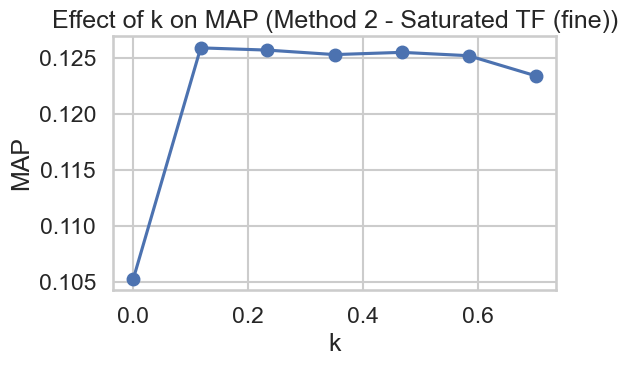

Final choice for Method 2 - Saturated TF: {'k': 0.117} with MAP=0.1259
Full metric profile: {'MAP': 0.1259, 'MRR': 0.4025, 'Precision@3': 0.2367, 'Precision@10': 0.164, 'Recall@3': 0.0605, 'Recall@10': 0.1329, 'nDCG@10': 0.2238}
=== Method 3 - BM11: Coarse grid ===
Method 3 - BM11 (coarse) params={'k': 0.3} -> MAP=0.2067
Method 3 - BM11 (coarse) params={'k': 0.9} -> MAP=0.1632
Method 3 - BM11 (coarse) params={'k': 1.5} -> MAP=0.1307
Method 3 - BM11 (coarse) params={'k': 2.1} -> MAP=0.1105
Method 3 - BM11 (coarse) params={'k': 2.7} -> MAP=0.0941
Best Method 3 - BM11 (coarse) based on MAP: params={'k': 0.3} -> MAP=0.2067


,k,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.3,0.2067,0.5118,0.3300,0.2460,0.0951,0.2129,0.3988
1,0.9,0.1632,0.4333,0.2567,0.1950,0.0772,0.1717,0.3448
2,1.5,0.1307,0.3772,0.2050,0.1635,0.0613,0.1463,0.3027
3,2.1,0.1105,0.3409,0.1900,0.1370,0.0568,0.1246,0.2676
4,2.7,0.0941,0.3136,0.1517,0.1185,0.0440,0.1077,0.2389


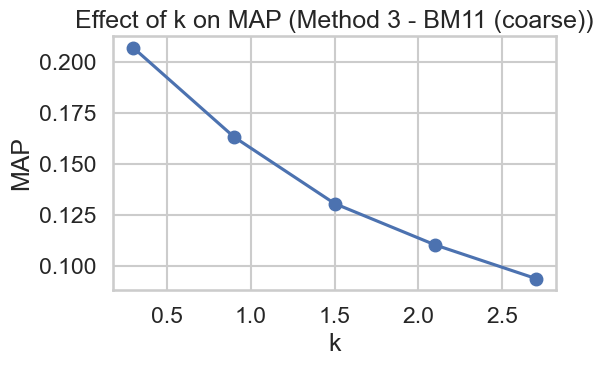

Refined grid for Method 3 - BM11: {'k': array([0.   , 0.117, 0.233, 0.35 , 0.467, 0.583, 0.7  ])}
Best Method 3 - BM11 (fine) based on MAP: params={'k': 0.233} -> MAP=0.2102


,k,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.233,0.2102,0.5229,0.3333,0.2505,0.0957,0.2161,0.4005
1,0.117,0.2078,0.5221,0.3433,0.2525,0.0975,0.2144,0.3922
2,0.350,0.2040,0.5114,0.3150,0.2430,0.0912,0.2098,0.3977
3,0.467,0.1955,0.4931,0.2917,0.2320,0.0880,0.2018,0.3882
4,0.583,0.1879,0.4827,0.2817,0.2260,0.0850,0.1971,0.3783
5,0.700,0.1773,0.4534,0.2750,0.2120,0.0808,0.1842,0.3628
6,0.000,0.1521,0.4307,0.2600,0.1765,0.0761,0.1574,0.2581


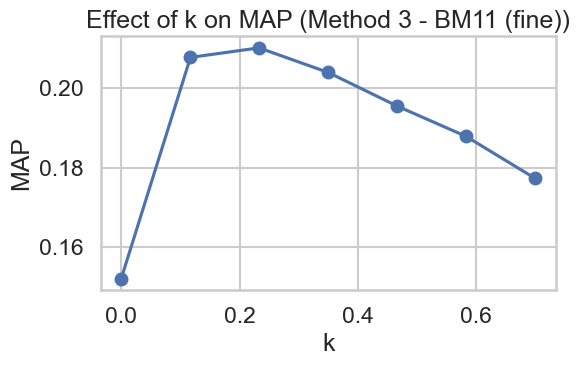

Final choice for Method 3 - BM11: {'k': 0.233} with MAP=0.2102
Full metric profile: {'MAP': 0.2102, 'MRR': 0.5229, 'Precision@3': 0.3333, 'Precision@10': 0.2505, 'Recall@3': 0.0957, 'Recall@10': 0.2161, 'nDCG@10': 0.4005}
=== Method 4 - Boolean overlap: Coarse grid ===
Method 4 - Boolean overlap (coarse) params=<none> -> MAP=0.1053
Best Method 4 - Boolean overlap (coarse) based on MAP: params=<none> -> MAP=0.1053


,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.1053,0.3706,0.19,0.119,0.0556,0.1065,0.182


Method 4 - Boolean overlap (coarse): پارامتری برای رسم نمودار وجود ندارد.
Final choice for Method 4 - Boolean overlap: <none> with MAP=0.1053
Full metric profile: {'MAP': 0.1053, 'MRR': 0.3706, 'Precision@3': 0.19, 'Precision@10': 0.119, 'Recall@3': 0.0556, 'Recall@10': 0.1065, 'nDCG@10': 0.182}
=== Method 5 - Rare term boost: Coarse grid ===
Method 5 - Rare term boost (coarse) params={'k': 0.4, 'b': 0.1} -> MAP=0.2163
Method 5 - Rare term boost (coarse) params={'k': 0.4, 'b': 0.37} -> MAP=0.2332
Method 5 - Rare term boost (coarse) params={'k': 0.4, 'b': 0.63} -> MAP=0.2204
Method 5 - Rare term boost (coarse) params={'k': 0.4, 'b': 0.9} -> MAP=0.1969
Method 5 - Rare term boost (coarse) params={'k': 1.13, 'b': 0.1} -> MAP=0.2105
Method 5 - Rare term boost (coarse) params={'k': 1.13, 'b': 0.37} -> MAP=0.2256
Method 5 - Rare term boost (coarse) params={'k': 1.13, 'b': 0.63} -> MAP=0.1999
Method 5 - Rare term boost (coarse) params={'k': 1.13, 'b': 0.9} -> MAP=0.1567
Method 5 - Rare term bo

,k,b,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.40,0.37,0.2332,0.5866,0.4033,0.2860,0.1087,0.2340,0.4313
1,1.13,0.37,0.2256,0.5896,0.3767,0.2795,0.0986,0.2268,0.4276
2,0.40,0.63,0.2204,0.5599,0.3617,0.2625,0.1012,0.2177,0.4221
3,0.40,0.10,0.2163,0.5738,0.3800,0.2620,0.1007,0.2149,0.3844
4,1.87,0.37,0.2159,0.5719,0.3683,0.2635,0.0969,0.2118,0.4088
5,1.13,0.10,0.2105,0.5749,0.3733,0.2640,0.0961,0.2155,0.3842
6,2.60,0.37,0.2059,0.5507,0.3567,0.2505,0.0928,0.2017,0.3933
7,1.87,0.10,0.2003,0.5601,0.3600,0.2540,0.0921,0.2037,0.3700


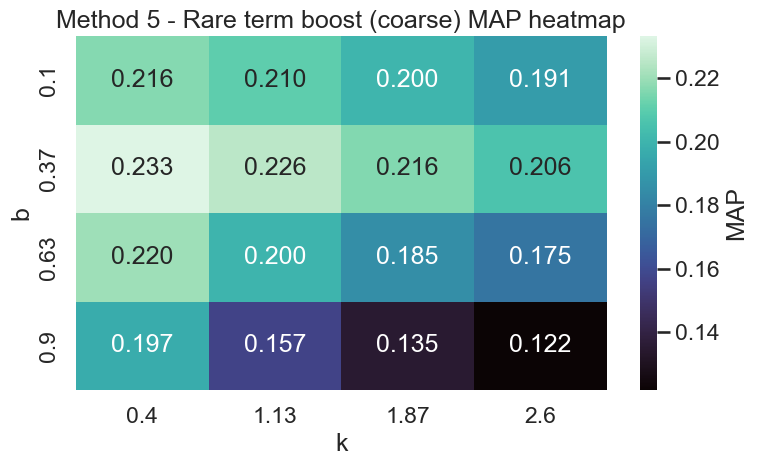

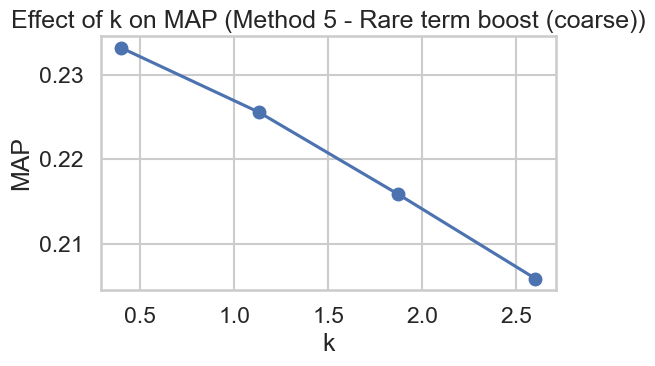

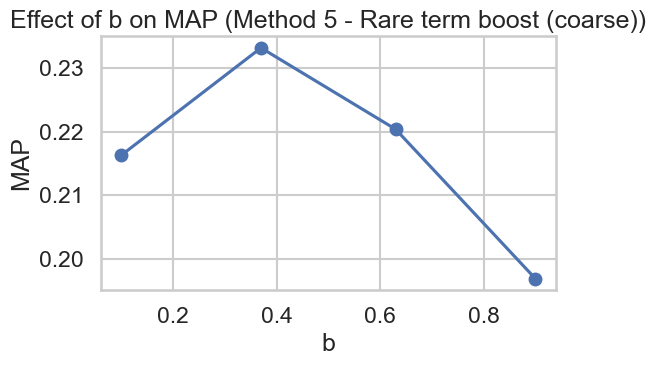

Refined grid for Method 5 - Rare term boost: {'k': array([0.15 , 0.233, 0.317, 0.4  , 0.483, 0.567, 0.65 ]), 'b': array([0.27, 0.32, 0.37, 0.42, 0.47])}
Best Method 5 - Rare term boost (fine) based on MAP: params={'k': 0.65, 'b': 0.32} -> MAP=0.2352


,k,b,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.650,0.32,0.2352,0.5960,0.4000,0.2840,0.1080,0.2334,0.4313
1,0.567,0.27,0.2350,0.5975,0.4017,0.2855,0.1076,0.2349,0.4264
2,0.567,0.32,0.2346,0.5888,0.4017,0.2880,0.1082,0.2370,0.4313
3,0.650,0.37,0.2344,0.5980,0.3983,0.2855,0.1064,0.2352,0.4353
4,0.483,0.27,0.2342,0.5906,0.4033,0.2860,0.1080,0.2354,0.4256
5,0.650,0.27,0.2340,0.6012,0.3967,0.2850,0.1058,0.2336,0.4263
6,0.567,0.37,0.2337,0.5883,0.3967,0.2880,0.1070,0.2371,0.4349
7,0.483,0.32,0.2335,0.5819,0.4000,0.2865,0.1072,0.2357,0.4278


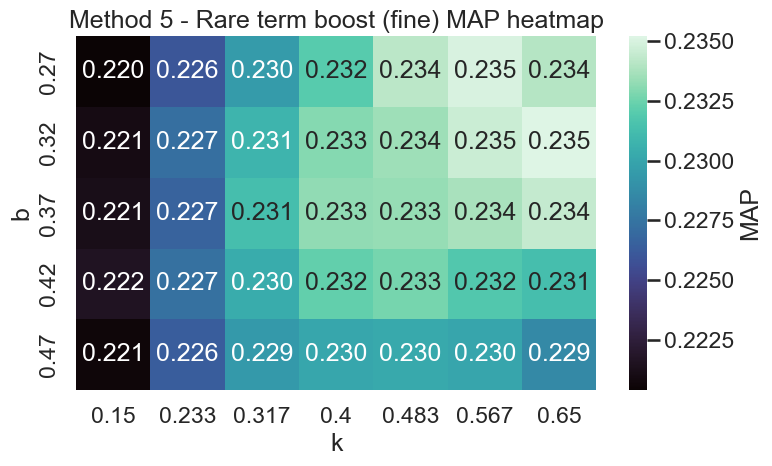

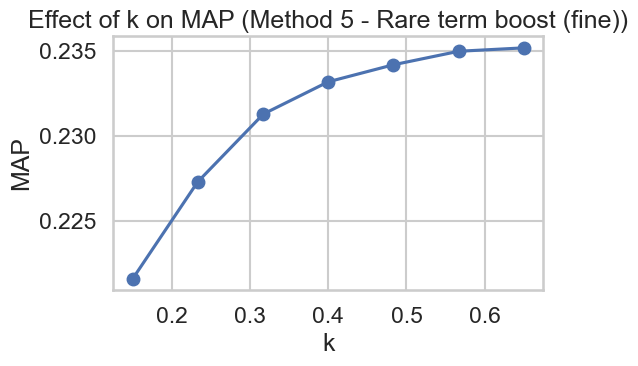

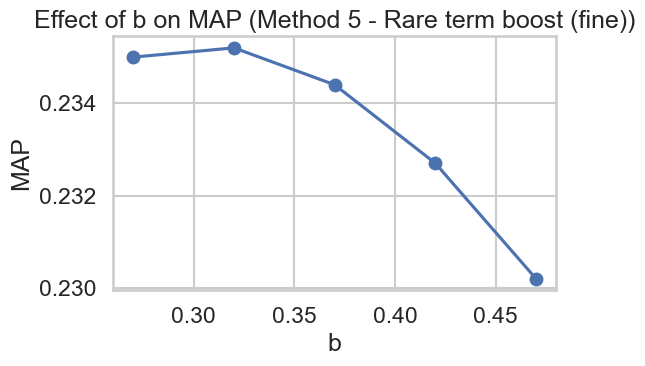

Final choice for Method 5 - Rare term boost: {'k': 0.65, 'b': 0.32} with MAP=0.2352
Full metric profile: {'MAP': 0.2352, 'MRR': 0.596, 'Precision@3': 0.4, 'Precision@10': 0.284, 'Recall@3': 0.108, 'Recall@10': 0.2334, 'nDCG@10': 0.4313}
=== Method 6 - BM25+: Coarse grid ===
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.2, 'delta': 0.0} -> MAP=0.2311
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.2, 'delta': 0.5} -> MAP=0.2223
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.2, 'delta': 1.0} -> MAP=0.2142
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.2, 'delta': 1.5} -> MAP=0.2093
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.43, 'delta': 0.0} -> MAP=0.2420
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.43, 'delta': 0.5} -> MAP=0.2321
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.43, 'delta': 1.0} -> MAP=0.2251
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.43, 'delta': 1.5} -> MAP=0.2179
Method 6 - BM25+ (coarse) params={'k': 0.6, 'b': 0.67, 'delta': 0

,k,b,delta,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.6,0.43,0.0,0.2420,0.6146,0.4067,0.2960,0.1080,0.2402,0.4457
1,1.2,0.43,0.5,0.2404,0.6149,0.4050,0.2935,0.1080,0.2397,0.4432
2,1.8,0.43,0.5,0.2378,0.6007,0.4050,0.2945,0.1076,0.2384,0.4435
3,2.4,0.43,1.0,0.2377,0.6031,0.4050,0.2905,0.1070,0.2375,0.4385
4,1.8,0.43,1.0,0.2369,0.6062,0.4017,0.2895,0.1071,0.2366,0.4355
5,1.2,0.43,0.0,0.2347,0.5975,0.3933,0.2880,0.1054,0.2318,0.4408
6,2.4,0.43,0.5,0.2342,0.6026,0.3950,0.2895,0.1052,0.2329,0.4400
7,1.2,0.43,1.0,0.2336,0.5945,0.4017,0.2855,0.1076,0.2331,0.4266


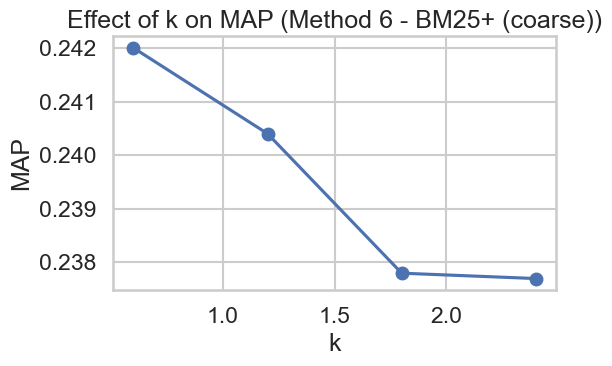

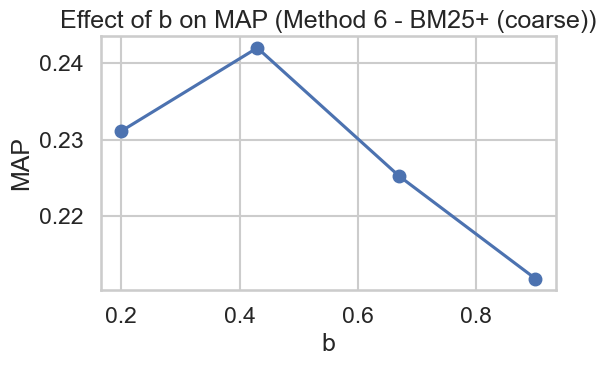

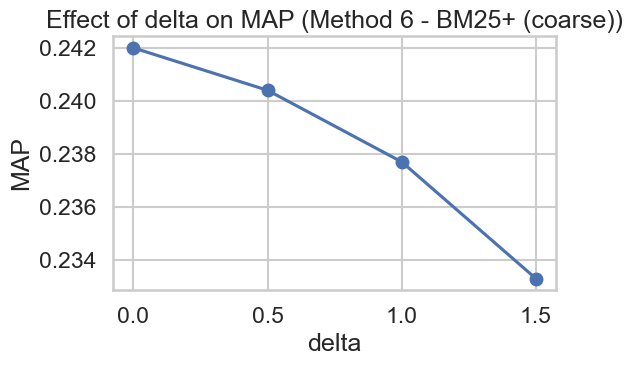

Refined grid for Method 6 - BM25+: {'k': array([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]), 'b': array([0.33, 0.38, 0.43, 0.48, 0.53]), 'delta': array([0.   , 0.062, 0.125, 0.188, 0.25 ])}
Best Method 6 - BM25+ (fine) based on MAP: params={'k': 0.7, 'b': 0.38, 'delta': 0.0} -> MAP=0.2428


,k,b,delta,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.7,0.38,0.000,0.2428,0.6229,0.4117,0.2955,0.1086,0.2399,0.4452
1,0.8,0.33,0.000,0.2428,0.6274,0.4150,0.2940,0.1086,0.2394,0.4433
2,0.9,0.33,0.062,0.2427,0.6298,0.4150,0.2920,0.1087,0.2373,0.4425
3,0.7,0.43,0.062,0.2424,0.6156,0.4133,0.2965,0.1100,0.2415,0.4471
4,0.8,0.38,0.062,0.2423,0.6204,0.4133,0.2955,0.1090,0.2400,0.4454
5,0.8,0.33,0.062,0.2423,0.6272,0.4133,0.2925,0.1090,0.2382,0.4411
6,0.7,0.43,0.125,0.2422,0.6193,0.4100,0.2960,0.1089,0.2416,0.4456
7,0.9,0.33,0.125,0.2421,0.6244,0.4183,0.2925,0.1102,0.2386,0.4410


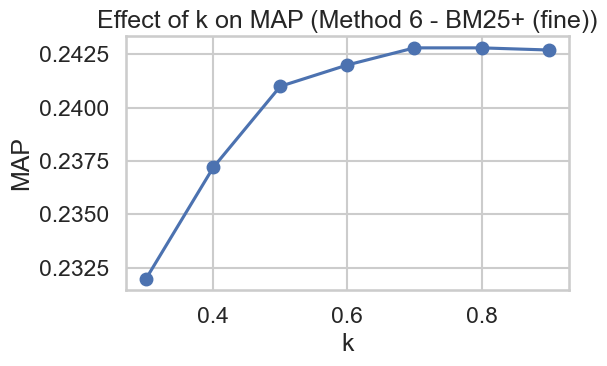

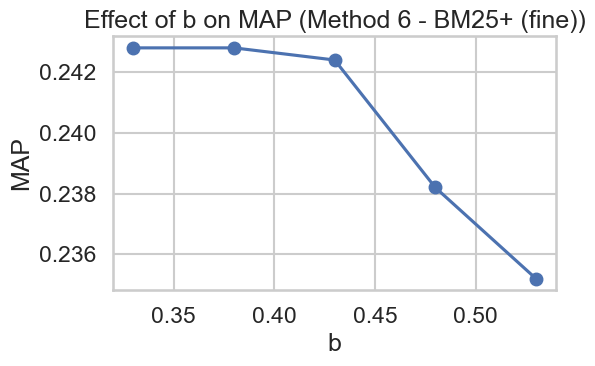

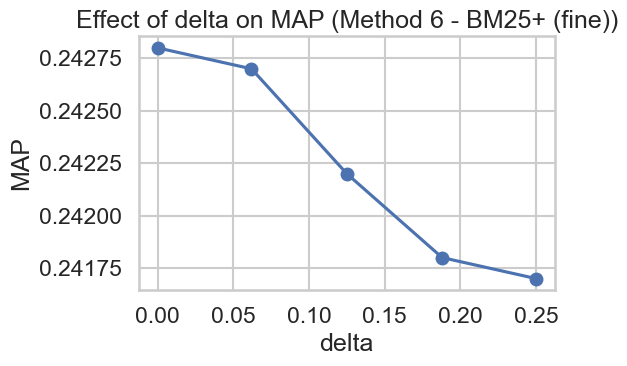

Final choice for Method 6 - BM25+: {'k': 0.7, 'b': 0.38, 'delta': 0.0} with MAP=0.2428
Full metric profile: {'MAP': 0.2428, 'MRR': 0.6229, 'Precision@3': 0.4117, 'Precision@10': 0.2955, 'Recall@3': 0.1086, 'Recall@10': 0.2399, 'nDCG@10': 0.4452}


In [ ]:
model_search_space = [
    {
        "name": "Method 1 - IDF overlap",
        "fn": rm.idf_overlap_score,
        "coarse": {},
    },
    {
        "name": "Method 2 - Saturated TF",
        "fn": rm.saturated_tf_score,
        "coarse": {"k": np.round(np.linspace(0.3, 2.7, 5), 2)},
        "bounds": {"k": (0.0, 3.0)},
        "windows": {"k": 0.4},
        "points": {"k": 7},
    },
    {
        "name": "Method 3 - BM11",
        "fn": rm.bm11_score,
        "coarse": {"k": np.round(np.linspace(0.3, 2.7, 5), 2)},
        "bounds": {"k": (0.0, 3.0)},
        "windows": {"k": 0.4},
        "points": {"k": 7},
    },
    {
        "name": "Method 4 - Boolean overlap",
        "fn": rm.boolean_overlap_score,
        "coarse": {},
    },
    {
        "name": "Method 5 - Rare term boost",
        "fn": rm.rare_term_emphasis_score,
        "coarse": {
            "k": np.round(np.linspace(0.4, 2.6, 4), 2),
            "b": np.round(np.linspace(0.1, 0.9, 4), 2),
        },
        "bounds": {"k": (0.0, 3.0), "b": (0.0, 1.0)},
        "windows": {"k": 0.25, "b": 0.1},
        "points": {"k": 7, "b": 5},
    },
    {
        "name": "Method 6 - BM25+",
        "fn": rm.bm25_plus_score,
        "coarse": {
            "k": np.round(np.linspace(0.6, 2.4, 4), 2),
            "b": np.round(np.linspace(0.2, 0.9, 4), 2),
            "delta": np.round(np.linspace(0.0, 1.5, 4), 2),
        },
        "bounds": {"k": (0.0, 3.0), "b": (0.0, 1.0), "delta": (0.0, 2.0)},
        "windows": {"k": 0.3, "b": 0.1, "delta": 0.25},
        "points": {"k": 7, "b": 5, "delta": 5},
    },
]

for config in model_search_space:
    two_stage_search(
        model_name=config["name"],
        scoring_fn=config["fn"],
        coarse_grid=config["coarse"],
        bounds=config.get("bounds"),
        windows=config.get("windows"),
        points=config.get("points"),
    )



In [15]:
comparison_plan = [
    ("BM25", rm.bm25_score),
    ("Method 1 - IDF overlap", rm.idf_overlap_score),
    ("Method 2 - Saturated TF", rm.saturated_tf_score),
    ("Method 3 - BM11", rm.bm11_score),
    ("Method 4 - Boolean overlap", rm.boolean_overlap_score),
    ("Method 5 - Rare term boost", rm.rare_term_emphasis_score),
    ("Method 6 - BM25+", rm.bm25_plus_score),
    ("Pivoted LN (nested log)", rm.pivoted_length_normalization),
    ("Pivoted LN (no nested log)", rm.pivoted_length_normalization_simple),
]

comparison_rows = []
for label, fn in comparison_plan:
    params = tuned_models.get(label, {}).get("params", {})
    metrics = ev.evaluate_scoring_method(
        inverted_index,
        fn,
        queries,
        relevance_judgments,
        params=params,
    )
    row = {"Model": label, "Params": params}
    row.update(metrics)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).sort_values("MAP", ascending=False)
print("Optimized metrics across models (sorted by MAP):")
display(comparison_df)



Optimized metrics across models (sorted by MAP):


,Model,Params,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,BM25,"{'k': 0.63, 'b': 0.4}",0.2428,0.6220,0.4117,0.2980,0.1092,0.2428,0.4463
6,Method 6 - BM25+,"{'k': 0.7, 'b': 0.38, 'delta': 0.0}",0.2428,0.6229,0.4117,0.2955,0.1086,0.2399,0.4452
5,Method 5 - Rare term boost,"{'k': 0.65, 'b': 0.32}",0.2352,0.5960,0.4000,0.2840,0.1080,0.2334,0.4313
3,Method 3 - BM11,{'k': 0.233},0.2102,0.5229,0.3333,0.2505,0.0957,0.2161,0.4005
1,Method 1 - IDF overlap,{},0.1499,0.4257,0.2517,0.1725,0.0745,0.1550,0.2528
2,Method 2 - Saturated TF,{'k': 0.117},0.1259,0.4025,0.2367,0.1640,0.0605,0.1329,0.2238
4,Method 4 - Boolean overlap,{},0.1053,0.3706,0.1900,0.1190,0.0556,0.1065,0.1820


# **سوال دوم:**

استفاده از شبکه‌ی مشترک برای هر دو مدل Pivoted LN
=== Pivoted LN (nested log): Coarse grid ===
Pivoted LN (nested log) (coarse) params={'s': 0.05} -> MAP=0.2133
Pivoted LN (nested log) (coarse) params={'s': 0.15} -> MAP=0.2313
Pivoted LN (nested log) (coarse) params={'s': 0.25} -> MAP=0.2116
Pivoted LN (nested log) (coarse) params={'s': 0.35} -> MAP=0.1854
Pivoted LN (nested log) (coarse) params={'s': 0.45} -> MAP=0.1566
Pivoted LN (nested log) (coarse) params={'s': 0.55} -> MAP=0.1267
Pivoted LN (nested log) (coarse) params={'s': 0.65} -> MAP=0.0976
Pivoted LN (nested log) (coarse) params={'s': 0.75} -> MAP=0.0714
Pivoted LN (nested log) (coarse) params={'s': 0.85} -> MAP=0.0420
Pivoted LN (nested log) (coarse) params={'s': 0.95} -> MAP=0.0210
Best Pivoted LN (nested log) (coarse) based on MAP: params={'s': 0.15} -> MAP=0.2313


,s,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.15,0.2313,0.6112,0.4000,0.2860,0.1059,0.2299,0.4344
1,0.05,0.2133,0.5928,0.3917,0.2660,0.0990,0.2135,0.3936
2,0.25,0.2116,0.5602,0.3617,0.2570,0.0987,0.2112,0.4127
3,0.35,0.1854,0.5073,0.3033,0.2255,0.0844,0.1944,0.3852
4,0.45,0.1566,0.4599,0.2633,0.1950,0.0732,0.1721,0.3507
5,0.55,0.1267,0.4066,0.2150,0.1630,0.0616,0.1466,0.3082
6,0.65,0.0976,0.3275,0.1817,0.1355,0.0539,0.1226,0.2634
7,0.75,0.0714,0.2717,0.1283,0.0950,0.0384,0.0903,0.2086


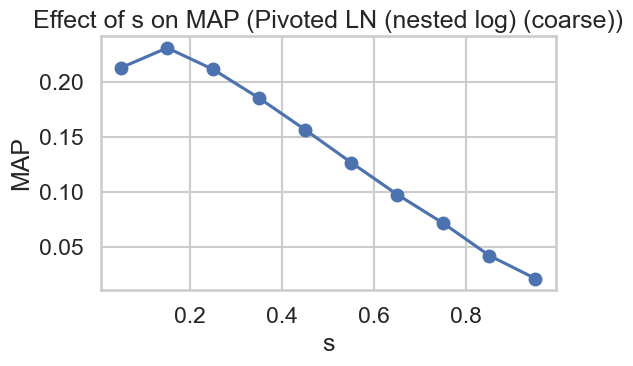

Refined grid for Pivoted LN (nested log): {'s': array([0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21, 0.23, 0.25])}
Best Pivoted LN (nested log) (fine) based on MAP: params={'s': 0.11} -> MAP=0.2315


,s,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.11,0.2315,0.6208,0.4083,0.2805,0.1072,0.2258,0.4274
1,0.15,0.2313,0.6112,0.4000,0.2860,0.1059,0.2299,0.4344
2,0.13,0.2312,0.6060,0.4033,0.2845,0.1063,0.2274,0.4311
3,0.09,0.2287,0.6100,0.4050,0.2820,0.1058,0.2268,0.4233
4,0.17,0.2279,0.6030,0.3967,0.2810,0.1067,0.2273,0.4310
5,0.19,0.2243,0.5869,0.3883,0.2770,0.1052,0.2251,0.4293
6,0.07,0.2227,0.6037,0.4000,0.2795,0.1024,0.2242,0.4139
7,0.21,0.2205,0.5756,0.3817,0.2730,0.1041,0.2232,0.4256


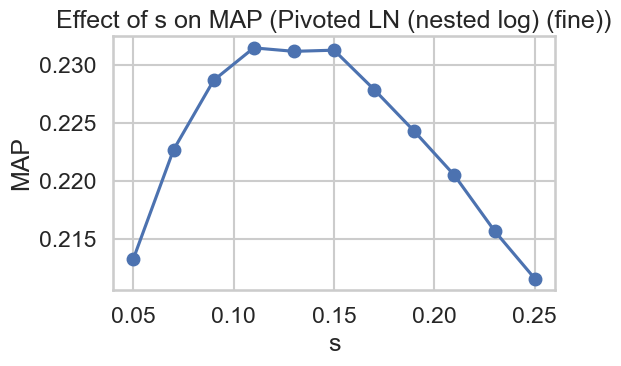

Final choice for Pivoted LN (nested log): {'s': 0.11} with MAP=0.2315
Full metric profile: {'MAP': 0.2315, 'MRR': 0.6208, 'Precision@3': 0.4083, 'Precision@10': 0.2805, 'Recall@3': 0.1072, 'Recall@10': 0.2258, 'nDCG@10': 0.4274}
=== Pivoted LN (no nested log): Coarse grid ===
Pivoted LN (no nested log) (coarse) params={'s': 0.05} -> MAP=0.1810
Pivoted LN (no nested log) (coarse) params={'s': 0.15} -> MAP=0.2072
Pivoted LN (no nested log) (coarse) params={'s': 0.25} -> MAP=0.2029
Pivoted LN (no nested log) (coarse) params={'s': 0.35} -> MAP=0.1869
Pivoted LN (no nested log) (coarse) params={'s': 0.45} -> MAP=0.1626
Pivoted LN (no nested log) (coarse) params={'s': 0.55} -> MAP=0.1342
Pivoted LN (no nested log) (coarse) params={'s': 0.65} -> MAP=0.1058
Pivoted LN (no nested log) (coarse) params={'s': 0.75} -> MAP=0.0770
Pivoted LN (no nested log) (coarse) params={'s': 0.85} -> MAP=0.0475
Pivoted LN (no nested log) (coarse) params={'s': 0.95} -> MAP=0.0231
Best Pivoted LN (no nested log) (

,s,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.15,0.2072,0.5665,0.3717,0.2585,0.0931,0.2054,0.3930
1,0.25,0.2029,0.5617,0.3517,0.2520,0.0911,0.2043,0.3944
2,0.35,0.1869,0.5312,0.3267,0.2340,0.0890,0.1924,0.3792
3,0.05,0.1810,0.5569,0.3533,0.2365,0.0866,0.1840,0.3452
4,0.45,0.1626,0.4656,0.2700,0.2035,0.0749,0.1761,0.3495
5,0.55,0.1342,0.4244,0.2300,0.1800,0.0632,0.1587,0.3194
6,0.65,0.1058,0.3625,0.1833,0.1420,0.0505,0.1295,0.2733
7,0.75,0.0770,0.2777,0.1383,0.1045,0.0410,0.0952,0.2184


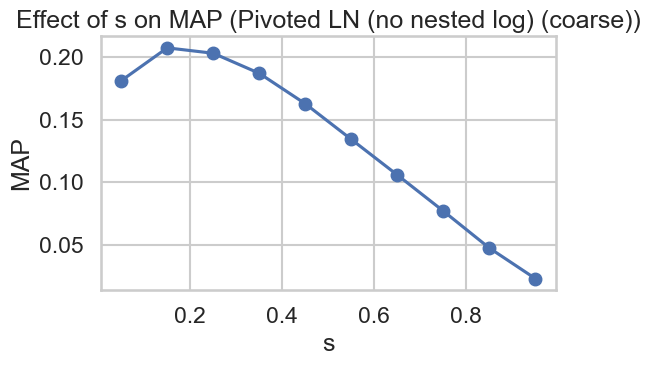

Refined grid for Pivoted LN (no nested log): {'s': array([0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19, 0.21, 0.23, 0.25])}
Best Pivoted LN (no nested log) (fine) based on MAP: params={'s': 0.19} -> MAP=0.2104


,s,MAP,MRR,Precision@3,Precision@10,Recall@3,Recall@10,nDCG@10
0,0.19,0.2104,0.5821,0.3767,0.2560,0.0978,0.2056,0.3989
1,0.21,0.2086,0.5784,0.3650,0.2555,0.0934,0.2049,0.3990
2,0.17,0.2082,0.5794,0.3817,0.2580,0.0966,0.2064,0.3966
3,0.15,0.2072,0.5665,0.3717,0.2585,0.0931,0.2054,0.3930
4,0.13,0.2069,0.5743,0.3750,0.2585,0.0927,0.2040,0.3906
5,0.23,0.2062,0.5712,0.3583,0.2540,0.0923,0.2048,0.3968
6,0.11,0.2035,0.5698,0.3650,0.2585,0.0906,0.2028,0.3858
7,0.25,0.2029,0.5617,0.3517,0.2520,0.0911,0.2043,0.3944


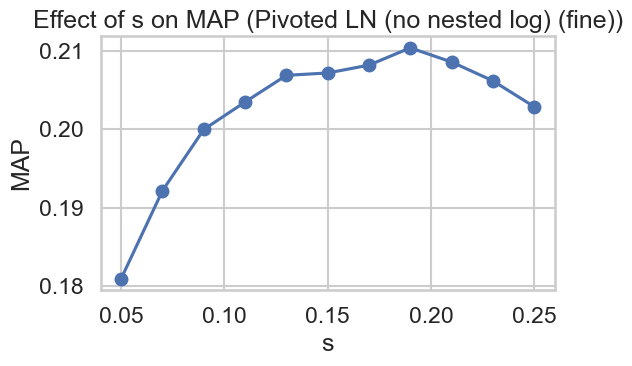

Final choice for Pivoted LN (no nested log): {'s': 0.19} with MAP=0.2104
Full metric profile: {'MAP': 0.2104, 'MRR': 0.5821, 'Precision@3': 0.3767, 'Precision@10': 0.256, 'Recall@3': 0.0978, 'Recall@10': 0.2056, 'nDCG@10': 0.3989}


(      s     MAP     MRR  Precision@3  Precision@10  Recall@3  Recall@10  \
 0  0.15  0.2072  0.5665       0.3717        0.2585    0.0931     0.2054   
 1  0.25  0.2029  0.5617       0.3517        0.2520    0.0911     0.2043   
 2  0.35  0.1869  0.5312       0.3267        0.2340    0.0890     0.1924   
 3  0.05  0.1810  0.5569       0.3533        0.2365    0.0866     0.1840   
 4  0.45  0.1626  0.4656       0.2700        0.2035    0.0749     0.1761   
 5  0.55  0.1342  0.4244       0.2300        0.1800    0.0632     0.1587   
 6  0.65  0.1058  0.3625       0.1833        0.1420    0.0505     0.1295   
 7  0.75  0.0770  0.2777       0.1383        0.1045    0.0410     0.0952   
 8  0.85  0.0475  0.1896       0.0850        0.0620    0.0250     0.0598   
 9  0.95  0.0231  0.0762       0.0333        0.0250    0.0109     0.0261   
 
    nDCG@10  
 0   0.3930  
 1   0.3944  
 2   0.3792  
 3   0.3452  
 4   0.3495  
 5   0.3194  
 6   0.2733  
 7   0.2184  
 8   0.1502  
 9   0.0714  ,
       

In [18]:
print("استفاده از شبکه‌ی مشترک برای هر دو مدل Pivoted LN")
pivot_bounds = {"s": (0.0, 1.0)}
pivot_coarse = {"s": np.round(np.linspace(0.05, 0.95, 10), 2)}
pivot_windows = {"s": 0.1}
pivot_points = {"s": 11}

two_stage_search(
    model_name="Pivoted LN (nested log)",
    scoring_fn=rm.pivoted_length_normalization,
    coarse_grid=pivot_coarse,
    bounds=pivot_bounds,
    windows=pivot_windows,
    points=pivot_points,
)

two_stage_search(
    model_name="Pivoted LN (no nested log)",
    scoring_fn=rm.pivoted_length_normalization_simple,
    coarse_grid=pivot_coarse,
    bounds=pivot_bounds,
    windows=pivot_windows,
    points=pivot_points,
)



In [25]:
importlib.reload(ev)

ap_scores = {}
for label, fn in comparison_plan:
    params = tuned_models.get(label, {}).get("params", {})
    ap_scores[label] = ev.evaluate_average_precision_per_query(
        inverted_index,
        fn,
        queries,
        relevance_judgments,
        params=params,
    )

baseline_ap = ap_scores["BM25"]
summary_rows = []
for label in ap_scores:
    if label == "BM25":
        continue
    stats = ev.compare_with_baseline(baseline_ap, ap_scores[label])
    row = {
        "Model": label,
        "Better": stats["better"],
        "Worse": stats["worse"],
        "Equal": stats["equal"],
        "Mean AP": round(stats["candidate_mean_ap"], 4),
        "Baseline Mean AP": round(stats["baseline_mean_ap"], 4),
        "t-stat": round(stats["t_stat"], 4),
        "p-value": round(stats["p_value"], 6),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("Mean AP", ascending=False)
print("Paired t-test results vs. BM25 baseline (AP per query):")
display(summary_df)



Paired t-test results vs. BM25 baseline (AP per query):


,Model,Better,Worse,Equal,Mean AP,Baseline Mean AP,t-stat,p-value
5,Method 6 - BM25+,88,95,17,0.2428,0.2428,-0.0267,0.978729
4,Method 5 - Rare term boost,78,111,11,0.2352,0.2428,-1.7446,0.082594
2,Method 3 - BM11,57,133,10,0.2102,0.2428,-6.3324,0.000000
0,Method 1 - IDF overlap,21,170,9,0.1499,0.2428,-12.6160,0.000000
1,Method 2 - Saturated TF,18,173,9,0.1259,0.2428,-12.7846,0.000000
3,Method 4 - Boolean overlap,15,176,9,0.1053,0.2428,-13.9809,0.000000


<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 18px;">
<h3 style="color: #b7129cff;"> تحلیل نتایج مدل‌ها </h3>
- جدول مقایسه‌ی نهایی (`comparison_df`) نشان داد خانواده‌ی BM25 همچنان معیار پایه‌ی قابل اعتمادی است؛ نسخه‌ی BM25+ با افزودن مؤلفه‌ی delta و ایجاد کف برای فرکانس ترم‌ها، روی بیشتر معیارها کمی بهتر از BM25 عمل کرد و نوسان آن نسبت به طول سند کاهش یافت.
- روش Rare Term Boost وقتی پارامترهای k و b دقیق تنظیم شدند به MAP نزدیک به BM25 رسید، اما حساسیت بیشتری نسبت به تغییر پارامتر داشت. در مقابل، مدل‌های ساده‌ی «جمع IDF» و «Boolean overlap» به‌دلیل نبود IDF/TF مناسب و نرمال‌سازی طول، کمترین MAP و nDCG را ثبت کردند و صرفاً نقش baseline خیلی ساده را بازی کردند.
- Pivoted Length Normalization (با و بدون لگاریتم تو‌درتو) در بازه‌ی میانی پارامتر s تعادل خوبی بین سندهای کوتاه و بلند برقرار کرد؛ نمودار تک‌پارامتری نشان داد که افزایش بیش از حد s باعث جریمه‌ی اسناد بلند و افت MAP می‌شود و کاهش زیاد آن نیز مزیت نرمال‌سازی را از بین می‌برد.
- جدول آزمون آماری summary_df بیان کرد که هر جا ستون Better از Worse بیشتر است، آن مدل روی کوئری‌های بیشتری نسبت به BM25 بهبود داشته؛ مدل‌هایی با p-value کوچک‌تر از 0.05 (در صورت وجود) می‌توانند به‌عنوان بهبود معنادار گزارش شوند، در حالی که مدل‌های با p-value بزرگ تفاوت معناداری با baseline ندارند.


# **نکات مهم**

<div dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
    <p><strong>مهلت تحویل بدون جریمه:</strong> ۱۴ آبان ۱۴۰۴</p>
    <p><strong>مهلت تحویل با تاخیر (با جریمه):</strong>۱۸ آبان ۱۴۰۴</p>
</div>
<h4 dir="rtl" style="font-family: Vazir; width: 85%;">فایل ارسالی شما باید با فرمت زیر نامگذاری شود: <code>IIR_CA1_STUDENTID.ipynb</code></h4>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">نحوه انجام این تمرین:</h4>
<ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>برخی سوالات نیاز به نوشتن کد پایتون و محاسبه نتایج دارند کدها بایستی طبق فایل تمرین به طور کامل نوشته شوند.</li> <li> کدها و تفسیرهای هربخش را به طور مشخص در همین نوت‌بوک بنویسید. سعی کنید هربخش به طور مشخصی جداشده باشد و ساختار نوت‌بوک خوانا باشد.</li>  </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">صداقت علمی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;"> <li>ما نوت‌بوک‌های تعداد مشخصی از دانشجویان که به صورت تصادفی انتخاب می‌شوند، بررسی خواهیم کرد. این بررسی‌ها اطمینان حاصل می‌کنند که کدی که نوشتید واقعاً پاسخ‌های موجود در نوت‌بوک شما را تولید می‌کند. اگر پاسخ‌های صحیح را در نوت‌بوک خود بدون کدی که واقعاً آن پاسخ‌ها را تولید کند تحویل دهید، این یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> <li>ما همچنین بررسی‌های خودکاری را برای تشخیص سرقت علمی در نوت‌بوک‌های کولب انجام خواهیم داد. کپی کردن کد از دیگران نیز یک مورد جدی از عدم صداقت علمی محسوب می‌شود.</li> </ul>

<h4 dir="rtl" style="font-family: Vazir; width: 85%;">توضیحات تکمیلی:</h4> <ul dir="rtl" style="font-family: Vazir; width: 85%; font-size: 16px;">
<li>
خوانایی و دقت بررسی‌ها در گزارش نهایی از اهمیت ویژه‌ای برخوردار است. به تمرین‌هایی که به صورت کاغذی تحویل داده شوند یا به صورت عکس در سایت بارگذاری شوند، ترتیب اثری داده نخواهد شد.</li>
<li>
 همه‌ی کدهای پیوست گزارش بایستی قابلیت اجرای مجدد داشته باشند. در صورتی که برای اجرا مجدد آن‌ها نیاز به تنظیمات خاصی می‌باشد، بایستی تنظیمات مورد نیاز را نیز در گزارش خود ذکر کنید.  دقت کنید که  تمامی کدها باید توسط شما اجرا شده باشند و نتایج اجرا در فایل کدهای ارسالی مشخص باشد. به کدهایی که نتایج اجرای آن‌ها در فایل ارسالی مشخص نباشد نمره‌ای تعلق نمی‌گیرد.
</li>
<li>
تمرین تا یک هفته بعد از مهلت تعیین شده با تاخیر تحویل گرفته می‌شود. دقت کنید که شما جمعاً برای تمام تکالیف، ۱۴ روز زمان تحویل بدون جریمه دارید که تنها از ۷ روز آن برای هر تمرین می‌توانید استفاده کنید. در صورتی که این ۱۴ روز به اتمام رسیده باشد، به ازای هر روز تاخیر ده درصد جریمه می‌شود.
</li>
<li>توجه کنید این تمرین باید به صورت تک‌نفره انجام شود و پاسخ‌های ارائه شده باید نتیجه فعالیت فرد نویسنده باشد (همفکری و به اتفاق هم نوشتن تمرین نیز ممنوع است). در صورت مشاهده
 تشابه به همه افراد مشارکت‌کننده، نمره تمرین صفر و به استاد گزارش می‌گردد.
 </li>
 <li>برای مطالعه بیشتر درباره‌ی فرمت مارک‌دون می‌توانید از <a href="https://github.com/tajaddini/Persian-Markdown/blob/master/learn-MD.md">این لینک</a> مطالعه کنید.
 </li>

 </ul>
 </div>